In [18]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "text.usetex": False,
    "mathtext.fontset": "stix",
})

In [19]:
# Fetch dataset
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

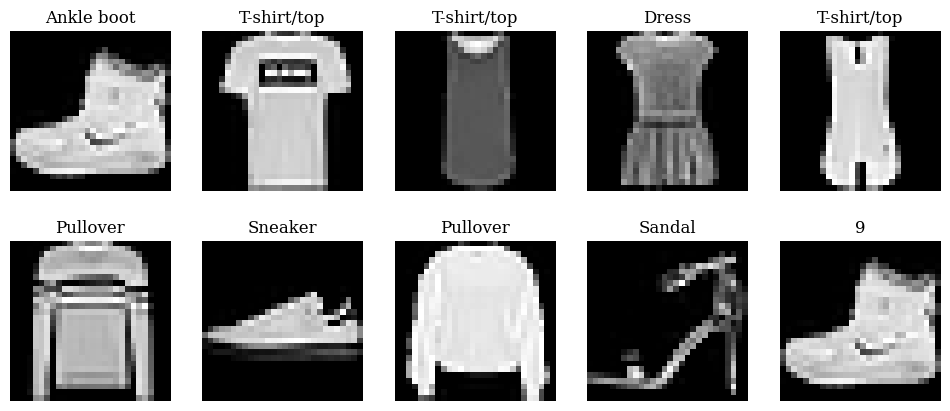

In [20]:
import matplotlib.pyplot as plt

#Visualising dataset
plt.figure(figsize=(12, 5))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.savefig('fashion_mnist_dataset.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [21]:
print("Training data shape before preprocessing:", x_train.shape)
print("Training labels shape before preprocessing:", y_train.shape)
print("Testing data shape before preprocessing:", x_test.shape)
print("Testing labels shape before preprocessing:", y_test.shape)

#Preprocessing
from tensorflow.keras.utils import to_categorical
x_train_flat = x_train.reshape(x_train.shape[0], 28*28)
x_test_flat = x_test.reshape(x_test.shape[0], 28*28)

x_train_flat = x_train_flat.astype('float32')/255.0
x_test_flat = x_test_flat.astype('float32')/255.0

y_train_onehot = to_categorical(y_train)
y_test_onehot = to_categorical(y_test)

print("\nTraining data shape after preprocessing:", x_train_flat.shape)
print("Training labels shape after preprocessing:", y_train_onehot.shape)
print("Testing data shape after preprocessing:", x_test_flat.shape)
print("Testing labels shape after preprocessing:", y_test_onehot.shape)

Training data shape before preprocessing: (60000, 28, 28)
Training labels shape before preprocessing: (60000,)
Testing data shape before preprocessing: (10000, 28, 28)
Testing labels shape before preprocessing: (10000,)

Training data shape after preprocessing: (60000, 784)
Training labels shape after preprocessing: (60000, 10)
Testing data shape after preprocessing: (10000, 784)
Testing labels shape after preprocessing: (10000, 10)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

#Baseline model definition
model = Sequential(
    [
        Dense(128, activation = "relu", input_shape = (784,)),
        Dense(64, activation= "relu"),
        Dense(10, activation="softmax")
    ]
)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [4]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(x_train_flat, y_train_onehot, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8168 - loss: 0.5166 - val_accuracy: 0.8385 - val_loss: 0.4427
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8625 - loss: 0.3782 - val_accuracy: 0.8552 - val_loss: 0.4071
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8743 - loss: 0.3423 - val_accuracy: 0.8594 - val_loss: 0.3867
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8829 - loss: 0.3168 - val_accuracy: 0.8723 - val_loss: 0.3561
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8896 - loss: 0.2980 - val_accuracy: 0.8808 - val_loss: 0.3325
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8944 - loss: 0.2823 - val_accuracy: 0.8796 - val_loss: 0.3346
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8988 - loss: 0.2690 - val_accuracy: 0.8839 - val_loss: 0.3271
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9035 - loss: 0.257

In [5]:
y_pred = model.predict(x_test_flat)
y_pred = y_pred.argmax(axis=1)
y_true = y_test_onehot.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Accuracy: 0.8832
Precision: 0.8834539883611487
Recall: 0.8832
F1 Score: 0.8814410085921666
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.89      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.83      0.81      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.83      0.77      0.80      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.78      0.61      0.69      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.94      0.97      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



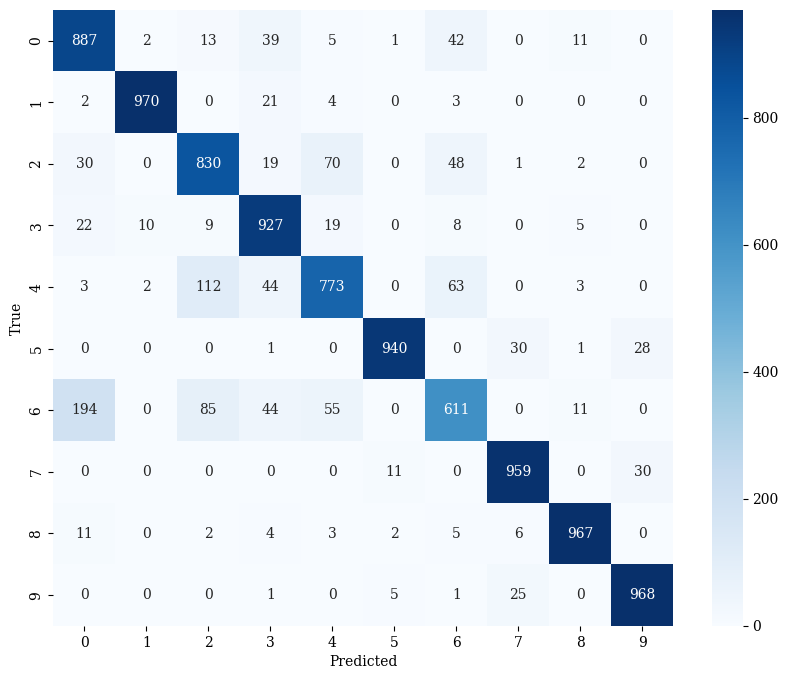

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score
import seaborn as sns

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
cm = confusion_matrix(y_true, y_pred)

# Model Performance
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('Confusion_Matrix', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

def create_model(hidden_layers=2, neurons=64, activation="relu",
                  dropout_rate=0.0, learning_rate=0.001, optimizer="adam", input_dim=None):
    if isinstance(neurons, int):
        neuron_counts = [neurons] * hidden_layers
    elif isinstance(neurons, (list, tuple)):
        if len(neurons) != hidden_layers:
            raise ValueError(f"Length of neurons ({len(neurons)}) must match hidden_layers ({hidden_layers})")
        neuron_counts = list(neurons)
    else:
        raise TypeError("neurons must be int or list/tuple of ints")

    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for count in neuron_counts:
        model.add(Dense(count, activation=activation))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation="softmax"))

    optimizer_map = {
        "adam": Adam(learning_rate=learning_rate),
        "sgd": SGD(learning_rate=learning_rate),
        "rmsprop": RMSprop(learning_rate=learning_rate),
    }
    opt = optimizer_map.get(optimizer.lower())
    if opt is None:
        raise ValueError(f"Unsupported optimizer '{optimizer}'")

    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

clf = KerasClassifier(
    model=create_model,
    model__input_dim=x_train_flat.shape[1],
    model__activation="relu",
    model__dropout_rate=0.0,
    model__optimizer="adam",
    model__learning_rate=0.001,
    model__hidden_layers=2,
    model__neurons=64,
    epochs=10,
    batch_size=32,
    verbose=0,
)

param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__optimizer": ["adam", "sgd", "rmsprop"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
}

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    verbose=2,
    random_state=42,
)

idx = np.random.RandomState(42).choice(len(x_train_flat), size=15000, replace=False)
x_search, y_search = x_train_flat[idx], y_train[idx]
search_result = search.fit(x_search, y_search)

print("Best params:", search_result.best_params_)
print("Best CV accuracy:", search_result.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time=  27.5s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time=  19.3s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time=  13.4s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time=  13.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params: {'model__optimizer': 'sgd', 'model__neurons': 128, 'model__learning_rate': 0.1, 'model__hidden_layers': 1, 'model__dropout_rate': 0.0, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}
Best CV accuracy: 0.8645333333333334


In [13]:
best_params = {k.replace("model__", ""): v for k, v in search_result.best_params_.items()if k.startswith("model__")}
best_epochs = search_result.best_params_.get("epochs", 20)
best_batch_size = search_result.best_params_.get("batch_size", 32)

best_model = create_model(input_dim=x_train_flat.shape[1], **best_params)
best_model.fit(x_train_flat, y_train, epochs=best_epochs, batch_size=best_batch_size,
               validation_split=0.2)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8049 - loss: 0.5423 - val_accuracy: 0.8217 - val_loss: 0.4909
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8478 - loss: 0.4220 - val_accuracy: 0.8513 - val_loss: 0.4122
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8600 - loss: 0.3849 - val_accuracy: 0.8416 - val_loss: 0.4286
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8683 - loss: 0.3604 - val_accuracy: 0.8574 - val_loss: 0.3869
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8735 - loss: 0.3437 - val_accuracy: 0.8605 - val_loss: 0.3748
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8782 - loss: 0.3270 - val_accuracy: 0.8675 - val_loss: 0.3624
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8833 - loss: 0.3147 - val_accuracy: 0.8680 - val_loss: 0.3561
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8879 - loss: 0.3011

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred_probs = best_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8832
Precision: 0.8834539883611487
Recall: 0.8832
F1: 0.8814410085921666
[[887   2  13  39   5   1  42   0  11   0]
 [  2 970   0  21   4   0   3   0   0   0]
 [ 30   0 830  19  70   0  48   1   2   0]
 [ 22  10   9 927  19   0   8   0   5   0]
 [  3   2 112  44 773   0  63   0   3   0]
 [  0   0   0   1   0 940   0  30   1  28]
 [194   0  85  44  55   0 611   0  11   0]
 [  0   0   0   0   0  11   0 959   0  30]
 [ 11   0   2   4   3   2   5   6 967   0]
 [  0   0   0   1   0   5   1  25   0 968]]
              precision    recall  f1-score   support

           0       0.77      0.89      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.79      0.83      0.81      1000
           3       0.84      0.93      0.88      1000
           4       0.83      0.77      0.80      1000
           5       0.98      0.94      0.96      1000
           6       0.78      0.61      0.69      1000
          

In [24]:
print("=== Baseline vs Optimized ===")
print(f"{'Metric':<12}{'Baseline':<12}{'Optimized':<12}")
print(f"{'Accuracy':<12}{accuracy:<12.4f}{accuracy_score(y_test, y_pred):<12.4f}")
print(f"{'Precision':<12}{precision:<12.4f}{precision_score(y_test, y_pred, average='weighted'):<12.4f}")
print(f"{'Recall':<12}{recall:<12.4f}{recall_score(y_test, y_pred, average='weighted'):<12.4f}")
print(f"{'F1':<12}{f1:<12.4f}{f1_score(y_test, y_pred, average='weighted'):<12.4f}")

=== Baseline vs Optimized ===
Metric      Baseline    Optimized   
Accuracy    0.8832      0.8832      
Precision   0.8835      0.8835      
Recall      0.8832      0.8832      
F1          0.8814      0.8814      


In [25]:
#Additional Tasks
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
  def __init__(self, n=0.01, epochs=100, gate = ""):
    self.n = n
    self.epochs = epochs
    self.weights = None
    self.bias = 0
    self.errors = []
    self.weight_history = []
    self.bias_history = []
    self.gate  = gate

  def fit(self, x, y):
    self.weights = np.zeros(x.shape[1])
    self.bias = 0.0
    self.errors = []
    self.weight_history = []
    self.bias_history = []

    for epoch in range(self.epochs):
      errors_in_epochs = 0
      for i in range(len(x)):
        z = np.dot(x[i], self.weights) + self.bias
        y_pred = 1 if z>0 else 0
        error = y[i] - y_pred

        if error != 0:
            self.weights = self.weights + (self.n * error * x[i])
            self.bias = self.bias + (self.n * error)
            errors_in_epochs += 1
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
      print(f"--- End of Epoch {epoch+1}: Total Misclassifications = {errors_in_epochs} ---\n")
      self.errors.append(errors_in_epochs)
      if errors_in_epochs == 0:
        print(f"{self.gate} gate Perceptron converged after epoch {epoch+1}\n")
        break

  def predict(self, x):
    z = np.dot(x, self.weights) + self.bias
    return np.where(z > 0, 1, 0)

In [26]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])
p_xor = Perceptron(n=0.1, epochs=50, gate="XOR")
p_xor.fit(X_xor, y_xor)
#Proof that single layer perceptron doesn't work for XOR problem

--- End of Epoch 1: Total Misclassifications = 2 ---

--- End of Epoch 2: Total Misclassifications = 3 ---

--- End of Epoch 3: Total Misclassifications = 4 ---

--- End of Epoch 4: Total Misclassifications = 4 ---

--- End of Epoch 5: Total Misclassifications = 4 ---

--- End of Epoch 6: Total Misclassifications = 4 ---

--- End of Epoch 7: Total Misclassifications = 4 ---

--- End of Epoch 8: Total Misclassifications = 4 ---

--- End of Epoch 9: Total Misclassifications = 4 ---

--- End of Epoch 10: Total Misclassifications = 4 ---

--- End of Epoch 11: Total Misclassifications = 4 ---

--- End of Epoch 12: Total Misclassifications = 4 ---

--- End of Epoch 13: Total Misclassifications = 4 ---

--- End of Epoch 14: Total Misclassifications = 4 ---

--- End of Epoch 15: Total Misclassifications = 4 ---

--- End of Epoch 16: Total Misclassifications = 4 ---

--- End of Epoch 17: Total Misclassifications = 4 ---

--- End of Epoch 18: Total Misclassifications = 4 ---

--- End of Epoch 19

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype="float32")
y_xor = np.array([0,1,1,0], dtype="float32")

model = Sequential([
    Dense(4, input_dim=2, activation="sigmoid"),
    Dense(1, activation="sigmoid"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05), loss="binary_crossentropy")

class WeightTracker(tf.keras.callbacks.Callback):
    def __init__(self, interval=50):
        super().__init__()
        self.interval = interval
        self.epochs = []
        self.w1 = []
        self.w2 = []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) == 1 or (epoch + 1) % self.interval == 0:
            weights = self.model.get_weights()
            self.epochs.append(epoch + 1)
            self.w1.append(weights[0].copy())
            self.w2.append(weights[2].copy())

weight_tracker = WeightTracker(interval=50)

history = model.fit(X_xor, y_xor, epochs=500, batch_size=4, verbose=0, callbacks=[weight_tracker])

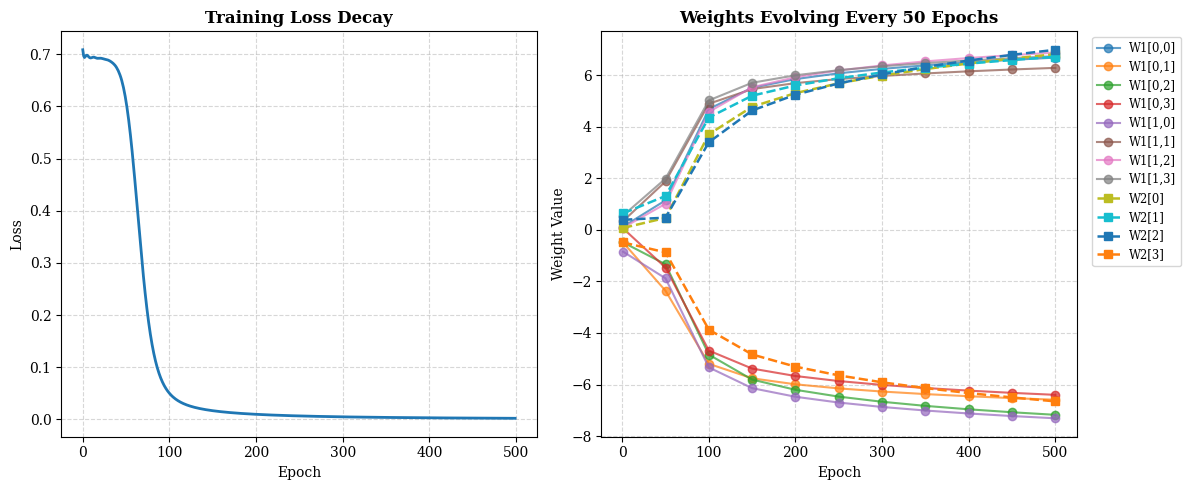

In [36]:
sampled_epochs = weight_tracker.epochs
w1_vals = np.array(weight_tracker.w1).reshape(len(sampled_epochs), -1)
w2_vals = np.array(weight_tracker.w2).reshape(len(sampled_epochs), -1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history["loss"], color="#1f77b4", lw=2)
ax1.set_title("Training Loss Decay", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.5)

for i in range(w1_vals.shape[1]):
    ax2.plot(sampled_epochs, w1_vals[:, i], "o-", label=f"W1[{i//4},{i%4}]", alpha=0.7)
for i in range(w2_vals.shape[1]):
    ax2.plot(sampled_epochs, w2_vals[:, i], "s--", label=f"W2[{i}]", lw=1.8)

ax2.set_title("Weights Evolving Every 50 Epochs", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Weight Value")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(fontsize="small", loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()

plt.show()